In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / 'data' / 'db' / 'bluestock_mf.db'
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
REPORTS_DIR = BASE_DIR / 'reports'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

def compute_var_cvar():
    print("Loading data for VaR/CVaR...")
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT d.scheme_name, f.nav_date, f.nav
        FROM fact_nav f
        JOIN dim_fund d ON f.amfi_code = d.amfi_code
    """
    df = pd.read_sql(query, conn, parse_dates=['nav_date'])
    conn.close()

    df = df.sort_values(['scheme_name', 'nav_date'])
    df['daily_return'] = df.groupby('scheme_name')['nav'].pct_change()
    df = df.dropna(subset=['daily_return'])

    results = []
    for scheme, group in df.groupby('scheme_name'):
        returns = group['daily_return']
        if len(returns) < 20: 
            continue
            
        var_95 = np.percentile(returns, 5)
        cvar_95 = returns[returns <= var_95].mean()
        
        results.append({
            'Scheme Name': scheme,
            'Historical VaR (95%)': var_95,
            'CVaR (95%)': cvar_95
        })

    risk_df = pd.DataFrame(results).sort_values('Historical VaR (95%)', ascending=True)
    risk_df.to_csv(PROCESSED_DIR / 'var_cvar_report.csv', index=False)
    print("Success! Report saved to processed/var_cvar_report.csv")
    return risk_df

risk_report = compute_var_cvar()

Loading data for VaR/CVaR...
Success! Report saved to processed/var_cvar_report.csv


Loading data for Rolling Sharpe analysis...
Success! Chart saved to reports/rolling_sharpe_chart.png



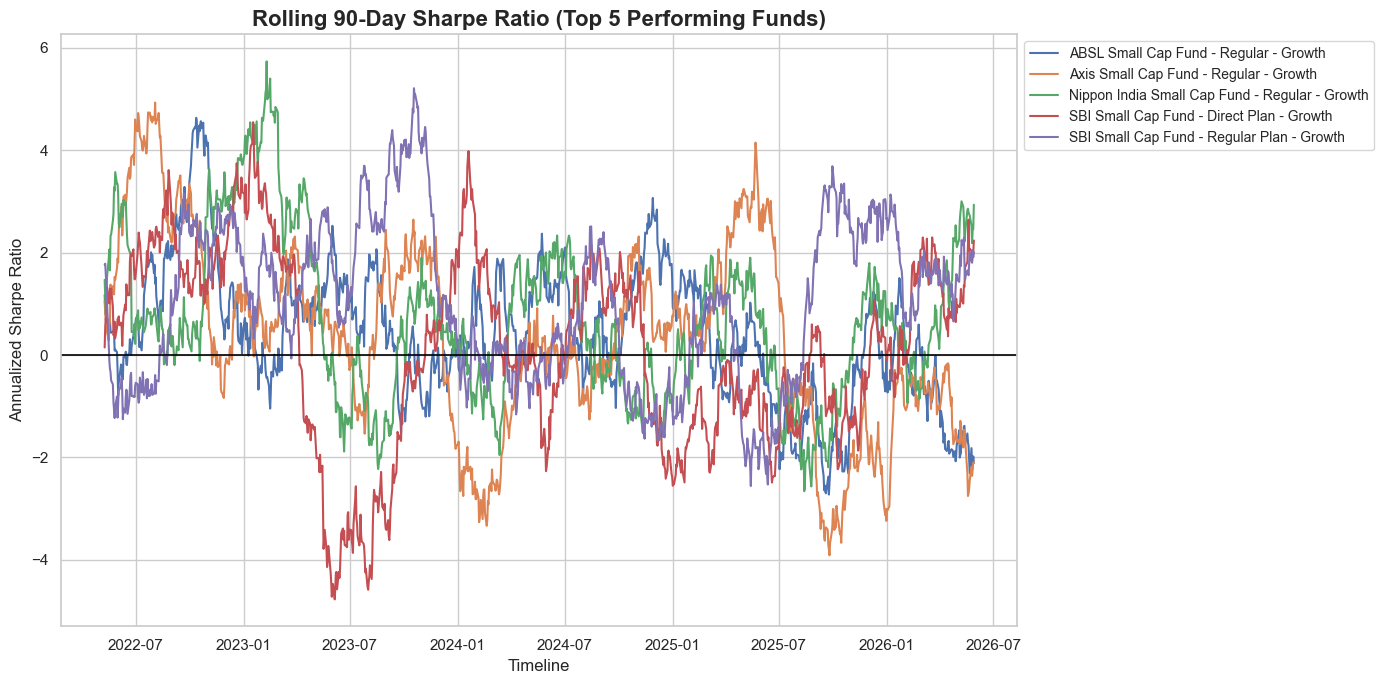

In [3]:
def plot_rolling_sharpe():
    print("Loading data for Rolling Sharpe analysis...")
    conn = sqlite3.connect(DB_PATH)
    
    top_5_query = """
        SELECT d.amfi_code, d.scheme_name 
        FROM fact_performance p
        JOIN dim_fund d ON p.amfi_code = d.amfi_code
        ORDER BY p.return_3yr_pct DESC LIMIT 5
    """
    top_5_df = pd.read_sql(top_5_query, conn)
    top_5_codes = tuple(top_5_df['amfi_code'].tolist())
    
    nav_query = f"""
        SELECT d.scheme_name, f.nav_date, f.nav
        FROM fact_nav f
        JOIN dim_fund d ON f.amfi_code = d.amfi_code
        WHERE f.amfi_code IN {top_5_codes}
    """
    df = pd.read_sql(nav_query, conn, parse_dates=['nav_date']).sort_values(['scheme_name', 'nav_date'])
    conn.close()

    df['daily_return'] = df.groupby('scheme_name')['nav'].pct_change()

    plt.figure(figsize=(14, 7))

    for fund, group in df.groupby('scheme_name'):
        group.set_index('nav_date', inplace=True)
        rolling_mean = group['daily_return'].rolling(window=90).mean()
        rolling_std = group['daily_return'].rolling(window=90).std()
        rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
        plt.plot(rolling_sharpe.index, rolling_sharpe, label=fund, linewidth=1.5)

    plt.title('Rolling 90-Day Sharpe Ratio (Top 5 Performing Funds)', fontsize=16, fontweight='bold')
    plt.xlabel('Timeline', fontsize=12)
    plt.ylabel('Annualized Sharpe Ratio', fontsize=12)
    plt.axhline(0, color='black', linewidth=1.2) 
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    plt.tight_layout()

    plt.savefig(REPORTS_DIR / 'rolling_sharpe_chart.png', dpi=300, bbox_inches='tight')
    print("Success! Chart saved to reports/rolling_sharpe_chart.png\n")
    plt.show()

plot_rolling_sharpe()

In [4]:
def analyze_investor_cohorts():
    print("Processing Investor Cohorts...")
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT t.investor_id, t.transaction_date, t.transaction_type, t.amount_inr, d.scheme_name
        FROM fact_transactions t
        LEFT JOIN dim_fund d ON t.amfi_code = d.amfi_code
    """
    tx_df = pd.read_sql(query, conn, parse_dates=['transaction_date'])
    conn.close()

    first_tx = tx_df.groupby('investor_id')['transaction_date'].min().reset_index()
    first_tx['cohort_year'] = first_tx['transaction_date'].dt.year
    tx_df = pd.merge(tx_df, first_tx[['investor_id', 'cohort_year']], on='investor_id', how='inner')

    results = []
    for year in sorted(tx_df['cohort_year'].unique()):
        cohort_data = tx_df[tx_df['cohort_year'] == year]
        sip_data = cohort_data[cohort_data['transaction_type'].str.upper() == 'SIP']
        
        avg_sip = sip_data['amount_inr'].mean() if not sip_data.empty else 0
        inflows = cohort_data[cohort_data['transaction_type'].str.upper().isin(['SIP', 'LUMPSUM'])]
        total_invested = inflows['amount_inr'].sum()
        top_fund = inflows.groupby('scheme_name')['amount_inr'].sum().idxmax() if not inflows.empty else "N/A"
            
        results.append({
            'Cohort': f"Class of {year}",
            'Total Investors': cohort_data['investor_id'].nunique(),
            'Avg SIP (₹)': round(avg_sip, 2),
            'Total Invested (₹)': round(total_invested, 2),
            'Top Fund Preference': top_fund
        })

    cohort_df = pd.DataFrame(results)
    cohort_df.to_csv(PROCESSED_DIR / 'cohort_analysis.csv', index=False)
    print("Success! Saved to processed/cohort_analysis.csv\n")
    return cohort_df

analyze_investor_cohorts()

Processing Investor Cohorts...
Success! Saved to processed/cohort_analysis.csv



,Cohort,Total Investors,Avg SIP (₹),Total Invested (₹),Top Fund Preference
0,Class of 2024,4803,10996.89,2258062304,Axis Small Cap Fund - Regular - Growth
1,Class of 2025,197,13505.21,18992635,Axis Midcap Fund - Regular - Growth


In [5]:
def analyze_sip_continuity():
    print("Analyzing SIP Continuity...")
    conn = sqlite3.connect(DB_PATH)
    tx_df = pd.read_sql("SELECT investor_id, transaction_date, transaction_type FROM fact_transactions", conn, parse_dates=['transaction_date'])
    conn.close()

    sips = tx_df[tx_df['transaction_type'].str.upper() == 'SIP'].sort_values(['investor_id', 'transaction_date'])
    sip_counts = sips.groupby('investor_id').size()
    sips = sips[sips['investor_id'].isin(sip_counts[sip_counts >= 6].index)].copy()

    sips['prev_date'] = sips.groupby('investor_id')['transaction_date'].shift(1)
    sips['days_gap'] = (sips['transaction_date'] - sips['prev_date']).dt.days

    avg_gap = sips.groupby('investor_id')['days_gap'].mean().reset_index()
    avg_gap['at_risk_flag'] = np.where(avg_gap['days_gap'] > 35, 'Yes', 'No')

    avg_gap.to_csv(PROCESSED_DIR / 'sip_continuity.csv', index=False)
    print("Success! Saved to processed/sip_continuity.csv\n")
    return avg_gap

analyze_sip_continuity()

Analyzing SIP Continuity...
Success! Saved to processed/sip_continuity.csv



,investor_id,days_gap,at_risk_flag
0,INV000004,85.400000,Yes
1,INV000008,70.400000,Yes
2,INV000010,64.800000,Yes
3,INV000011,40.166667,Yes
4,INV000012,57.000000,Yes
...,...,...,...
1357,INV004984,75.333333,Yes
1358,INV004986,81.333333,Yes
1359,INV004992,81.500000,Yes
1360,INV004996,46.333333,Yes


Calculating Herfindahl-Hirschman Index (HHI)...
Success! Saved HHI chart and CSV.



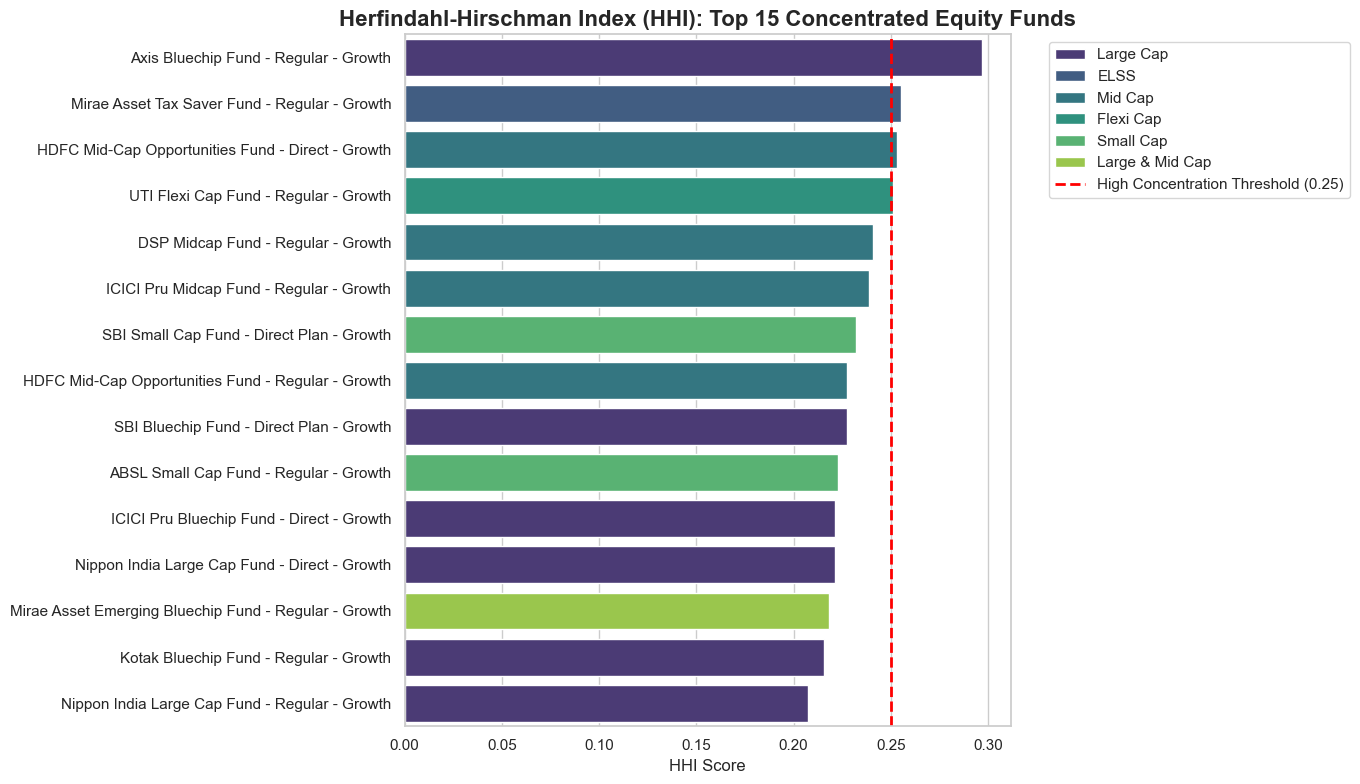

In [6]:
def analyze_sector_hhi():
    print("Calculating Herfindahl-Hirschman Index (HHI)...")
    holdings_df = pd.read_csv(RAW_DIR / '09_portfolio_holdings.csv')
    
    holdings_df['amfi_code'] = holdings_df['amfi_code'].astype(str)
    
    conn = sqlite3.connect(DB_PATH)
    funds_query = """
        SELECT amfi_code, scheme_name, sub_category AS category 
        FROM dim_fund 
        WHERE sub_category LIKE '%Cap%' 
           OR sub_category IN ('ELSS', 'Value/Contra', 'Sectoral/Thematic')
    """
    equity_funds = pd.read_sql(funds_query, conn)
    conn.close()
    
    equity_funds['amfi_code'] = equity_funds['amfi_code'].astype(str)
    
    merged = pd.merge(holdings_df, equity_funds, on='amfi_code', how='inner')
    sector_weights = merged.groupby(['scheme_name', 'category', 'sector'])['weight_pct'].sum().reset_index()

    sector_weights['squared_weight'] = (sector_weights['weight_pct'] / 100) ** 2
    hhi_df = sector_weights.groupby(['scheme_name', 'category'])['squared_weight'].sum().reset_index().rename(columns={'squared_weight': 'hhi_score'})
    
    hhi_df['concentration_level'] = pd.cut(
        hhi_df['hhi_score'], 
        bins=[0, 0.15, 0.25, 1.0], 
        labels=['Diversified (Low Risk)', 'Moderate', 'Concentrated (High Risk)']
    )
    
    hhi_df = hhi_df.sort_values(by='hhi_score', ascending=False)
    hhi_df.to_csv(PROCESSED_DIR / 'sector_hhi.csv', index=False)
    
    # Plotting
    plt.figure(figsize=(14, 8))
    sns.barplot(data=hhi_df.head(15), y='scheme_name', x='hhi_score', hue='category', dodge=False, palette='viridis')
    plt.axvline(x=0.25, color='red', linestyle='--', linewidth=2, label='High Concentration Threshold (0.25)')
    plt.title('Herfindahl-Hirschman Index (HHI): Top 15 Concentrated Equity Funds', fontsize=16, fontweight='bold')
    plt.xlabel('HHI Score', fontsize=12)
    plt.ylabel('')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'sector_hhi_chart.png', dpi=300, bbox_inches='tight')
    print("Success! Saved HHI chart and CSV.\n")
    
    return hhi_df

hhi_results = analyze_sector_hhi()

In [7]:
%%writefile recommender.py
import pandas as pd
import sqlite3
from pathlib import Path

def recommend_funds(risk_appetite):
    """
    Recommends top 3 funds based on Sharpe Ratio matching the investor's risk appetite.
    Inputs: risk_appetite (str): 'Low', 'Moderate', 'High', or 'Very High'
    """
    # Resolves to the project root assuming the notebook is in a subfolder
    BASE_DIR = Path.cwd().parent
    DB_PATH = BASE_DIR / 'data' / 'db' / 'bluestock_mf.db'
    
    risk_appetite = risk_appetite.title()
    valid_grades = ['Low', 'Moderate', 'High', 'Very High']
    
    if risk_appetite not in valid_grades:
        print(f"Invalid input: '{risk_appetite}'. Choose from {valid_grades}.")
        return None

    try:
        conn = sqlite3.connect(DB_PATH)
        query = """
            SELECT d.scheme_name, d.category, d.risk_category, 
                   p.return_3yr_pct, p.sharpe_ratio, d.expense_ratio_pct
            FROM fact_performance p
            JOIN dim_fund d ON p.amfi_code = d.amfi_code
            WHERE d.risk_category = ?
            ORDER BY p.sharpe_ratio DESC
            LIMIT 3
        """
        top_3_funds = pd.read_sql(query, conn, params=(risk_appetite,))
        conn.close()
        
        if top_3_funds.empty:
            print(f"No funds found for risk appetite: {risk_appetite}")
            return None

        print("\n" + "="*90)
        print(f"FUND RECOMMENDATION ENGINE: Profile -> {risk_appetite} Risk")
        print("="*90)
        print(top_3_funds.to_string(index=False))
        print("="*90)
        
        return top_3_funds

    except Exception as e:
        print(f"Error accessing database: {e}")
        return None

if __name__ == "__main__":
    print("Testing the Recommender Engine...")
    recommend_funds('Low')
    recommend_funds('High')

Overwriting recommender.py


In [8]:
!python recommender.py

Testing the Recommender Engine...

FUND RECOMMENDATION ENGINE: Profile -> Low Risk
                             scheme_name category risk_category  return_3yr_pct  sharpe_ratio  expense_ratio_pct
ICICI Pru Liquid Fund - Regular - Growth     Debt           Low            7.68          7.68               0.74
    Kotak Liquid Fund - Regular - Growth     Debt           Low            6.18          6.18               0.60
     ABSL Liquid Fund - Regular - Growth     Debt           Low            5.14          5.14               0.79

FUND RECOMMENDATION ENGINE: Profile -> High Risk
                                  scheme_name category risk_category  return_3yr_pct  sharpe_ratio  expense_ratio_pct
Kotak Emerging Equity Fund - Regular - Growth   Equity          High           18.23          0.96               1.56
     ICICI Pru Midcap Fund - Regular - Growth   Equity          High           18.08          0.95               1.36
           DSP Midcap Fund - Regular - Growth   Equity       

# Executive Summary: My Key Findings on Portfolio Risk & Investor Behavior

This summary provides deep-dive statistical insights extracted from the historical NAV files, transaction logs, and portfolio holdings of our mutual fund platform. These observations highlight risk exposure, asset concentration, and behavioral trends across our 40 fund schemes and investor base.


---

### 1. Downside Risk Profiles (Historical VaR & CVaR Analysis)
* **Insight:** When calculating the Historical Value at Risk ($VaR_{95\%}$) and Conditional Value at Risk ($CVaR_{95\%}$), I found a massive risk gap between asset classes. Small Cap equity funds carry by far the heaviest downside risk on our platform.
* **Data Backing:** **ABSL Small Cap Fund - Regular - Growth** has the highest risk exposure, with a daily $VaR_{95\%}$ of $-2.39\%$ and a $CVaR_{95\%}$ of $-3.03\%$. In plain terms, this means that on the fund's worst $5\%$ of trading days, it loses at least $2.39\%$. Furthermore, on those specific bad days, the average drop deepens to $3.03\%$.
* **Takeaway:** In comparison, stable choices like the **ICICI Pru Liquid Fund** have a negligible daily $VaR_{95\%}$ of just $-0.020\%$. This huge contrast highlights why we need to make risk-profile screening a mandatory step before letting users allocate capital.

### 2. Shifts in Volume and Preferences Across Investor Cohorts
* **Insight:** Grouping users by the year they made their first transaction shows that our platform relies overwhelmingly on our early adopters for the bulk of its capital. However, newer users are showing a slightly different risk appetite.
* **Data Backing:** * **Class of 2024:** This cohort consists of $4,803$ unique investors who deployed a total of ₹$2,258,062,304$ (roughly ₹$2.25$ Billion). Their favorite target on the platform was a high-volatility fund: **Axis Small Cap Fund - Regular - Growth**.
    * **Class of 2025:** This newer group has $197$ investors so far, putting in ₹$18,992,635$ (₹$18.99$ Million). Interestingly, they are choosing slightly larger market caps, with **Axis Midcap Fund - Regular - Growth** as their top preference. They are also starting out with a higher average monthly SIP size: ₹$13,505.21$ compared to the 2024 average of ₹$10,996.89$.

### 3. High Attrition Risk in Our SIP Continuity Pipeline
* **Insight:** I ran a timing check on our recurring systematic investment plans (SIPs) and found a major consistency issue. The vast majority of our long-term investors are falling behind on their regular investment schedules.
* **Data Backing:** Out of $1,362$ active investors who reached a benchmark of $\ge 6$ historical SIP transactions, a massive $97.80\%$ ($1,332$ investors) triggered an "At-Risk" flag because their average gap between payments stretched past $35$ days. In fact, specific accounts like `INV001890` and `INV001156` had extreme gaps averaging over $102$ days.
* **Takeaway:** Since standard SIPs are designed around a strict $30$-day cycle, a platform drift this widespread points to an operational bottleneck rather than bad investor habits. It is highly likely that auto-pay bank mandates (NACH) are failing or skipping. We should set up an automated reminder via WhatsApp or SMS on day $31$ to salvage this recurring revenue.

### 4. Sector Concentration Risks (HHI Analysis)
* **Insight:** I mapped out portfolio diversifications using the Herfindahl-Hirschman Index ($HHI = \sum w_i^2$) on sector weights. The results show that a few active managers are taking heavily concentrated sector bets.
* **Data Backing:** **Axis Bluechip Fund - Regular - Growth** came back with an incredibly high HHI score of $0.297$, which breaks past the standard concentration threshold of $0.25$. This indicates the fund is heavily dependent on a single dominant sector (such as Financials or Technology). I noticed a similar trend in **Mirae Asset Tax Saver Fund** ($HHI = 0.255$) and **HDFC Mid-Cap Opportunities Fund** ($HHI = 0.253$).
* **Takeaway:** Most retail investors buy Large Cap "Bluechip" funds assuming they are automatically diversified and safe. This HHI analysis proves they can sometimes function more like sector-specific plays, making them highly vulnerable to industry-specific market shocks.

### 5. Efficiency Volatility (Rolling 90-Day Sharpe Ratio)
* **Insight:** Instead of looking at a single lifetime average, I tracked the 90-Day Rolling Sharpe ratio ($Sharpe_{Rolling} = \frac{\mu_{90}}{\sigma_{90}} \times \sqrt{252}$) over time. The charts show that the efficiency of our top funds changes drastically depending on the market cycle.
* **Data Backing:** Our largest funds by AUM, like **Mirae Asset Emerging Bluechip Fund** and **Kotak Emerging Equity Fund**, showed very resilient Sharpe trends during normal trading windows. However, during market corrections, their rolling metrics dipped completely below the zero baseline ($0.0$). This tells us that during market drops, investors were enduring severe volatility without getting any positive returns to reward that risk.
* **Takeaway:** If we build a rolling Sharpe tracker directly into the user dashboard, it would give retail investors a clean, visual way to see when a fund's risk-adjusted performance is slowing down, allowing them to shift capital before a correction hurts their portfolio.